# Day 34 — Seaborn Statistical Plots
**Week 6: Pandas & Data Visualization**
**Topics covered:** `sns.histplot()`, `sns.boxplot()`, `sns.violinplot()`, `sns.barplot()`, `sns.scatterplot()`, `sns.heatmap()`, `sns.pairplot()`, `sns.countplot()`, `sns.stripplot()`, `hue` parameter, `palette`, `sns.set_theme()`, figure-level vs axes-level functions
 
---
 
## Dataset
**Name:** `Netflix Movies and TV Shows`
**URL:** `https://www.kaggle.com/datasets/shivamb/netflix-shows`
**Download:**
```python
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)
```
**Key Columns:** `show_id`, `type`, `title`, `director`, `country`, `date_added`, `release_year`, `rating`, `duration`, `listed_in`
 
---

**Q1.** Load the dataset and set the seaborn theme using `sns.set_theme(style="whitegrid")`. Print `.info()` and `.head()`. Filter the DataFrame to remove rows where `release_year` is missing or before 1990.

In [1]:
# Q1: Load Titanic dataset and display first 5 and last 3 rows

import pandas as pd
import kagglehub, os

# Get path to downloaded dataset
path = kagglehub.dataset_download("shivamb/netflix-shows")

# Find the CSV file inside the downloaded folder
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("=== First 5 rows ===")
print(df.head())

print("\n=== Last 3 rows ===")
print(df.tail(3))

100%|███████████████████████| 1.34M/1.34M [00:01<00:00, 853kB/s]

Extracting files...
=== First 5 rows ===
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2

In [2]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')


**Q2.** Use `sns.countplot()` to show the count of `type` (Movie vs TV Show). Add a title and use the palette `"pastel"`. Print the exact counts as well.

/tmp/ipykernel_77803/164179490.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="type", palette="pastel", ax=ax)


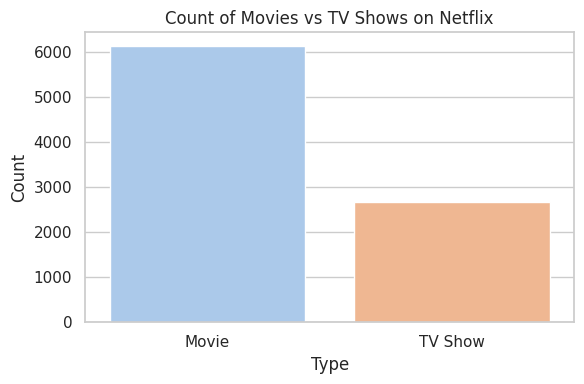

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [3]:
# Q2: Count plot of Netflix content type (Movie vs TV Show)

import seaborn as sns
import matplotlib.pyplot as plt

# Set theme for clean styling
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(6, 4))

# countplot counts occurrences of each category automatically
sns.countplot(data=df, x="type", palette="pastel", ax=ax)

ax.set_title("Count of Movies vs TV Shows on Netflix")
ax.set_xlabel("Type")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# Print exact counts
print(df["type"].value_counts())

### How it works

- `sns.countplot()` automatically counts how many rows belong to each category in the `x` column — no manual grouping needed.
- `palette="pastel"` applies soft, muted colors to the bars.
- `sns.set_theme(style="whitegrid")` adds a clean background grid for readability.
- `df["type"].value_counts()` prints the exact numbers so you can verify what the chart shows.

**Key takeaway:** `countplot` is the fastest way to visualize category frequencies — it counts for you automatically.

**Q3.** Use `sns.histplot()` to plot the distribution of `release_year`. Use `bins=30` and `kde=True` to overlay a density curve. Use `hue="type"` to show Movies and TV Shows separately.

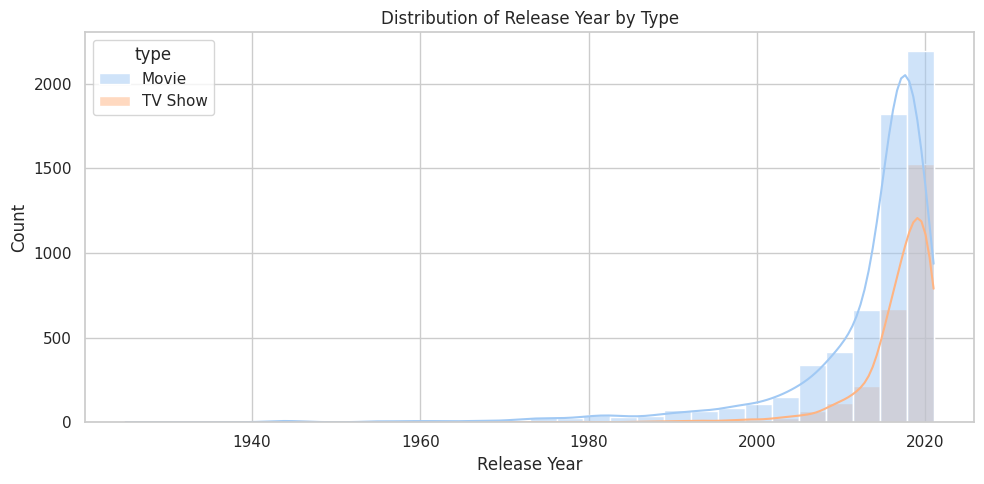

In [4]:
# Q3: Histogram of release_year distribution with KDE, split by type

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df,
    x="release_year",
    bins=30,
    kde=True,          # overlays a smooth density curve on the histogram
    hue="type",        # separate color per content type
    palette="pastel",
    ax=ax
)

ax.set_title("Distribution of Release Year by Type")
ax.set_xlabel("Release Year")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### How it works

- `sns.histplot()` divides `release_year` into 30 equal-width bins and counts how many titles fall in each bin.
- `kde=True` overlays a KDE curve (Kernel Density Estimate — a smoothed version of the histogram) so you can see the overall shape of the distribution.
- `hue="type"` splits the data by content type, drawing Movies and TV Shows in different colors on the same axes.
- Both the bars and the KDE curves are drawn per group, making it easy to compare when each type peaked in production.

**Key takeaway:** Combining `bins`, `kde=True`, and `hue` in `histplot` lets you see count, shape, and group differences all in one chart.

**Q4.** Create a new column `duration_minutes` by extracting the number from `duration` for Movies only (e.g., `"90 min"` → `90`). Use `sns.boxplot()` to show the distribution of `duration_minutes`. Add a title.

In [5]:
# Q4: Extract movie duration and plot boxplot distribution

# Step 1: Filter Movies only and extract numeric minutes from "duration" column
movies_df = df[df["type"] == "Movie"].copy()
movies_df["duration_minutes"] = (
    movies_df["duration"]
    .str.extract(r"(\d+)")   # grab the number part e.g. "90 min" → "90"
    .astype(int)
)

# Step 2: Boxplot of duration_minutes
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=movies_df,
    y="duration_minutes",
    palette="pastel",
    ax=ax
)

ax.set_title("Distribution of Movie Durations (in Minutes)")
ax.set_ylabel("Duration (minutes)")

plt.tight_layout()
plt.show()

# Print summary stats to verify
print(movies_df["duration_minutes"].describe())

ValueError: cannot convert float NaN to integer

/tmp/ipykernel_77803/1761523229.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


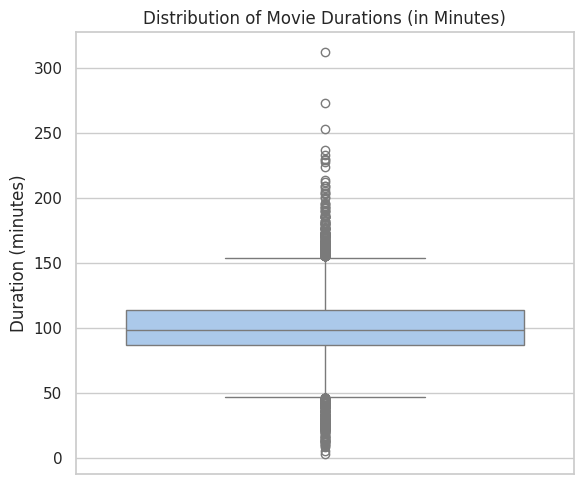

count       6128.0
mean     99.577187
std      28.290593
min            3.0
25%           87.0
50%           98.0
75%          114.0
max          312.0
Name: duration_minutes, dtype: Float64


In [6]:
# Q4: Extract movie duration and plot boxplot distribution

# Step 1: Filter Movies only
movies_df = df[df["type"] == "Movie"].copy()

# Step 2: Extract numeric minutes, drop rows where duration is null
movies_df["duration_minutes"] = (
    movies_df["duration"]
    .str.extract(r"(\d+)")      # "90 min" → "90"
    .squeeze()                  # convert single-column DataFrame → Series
    .astype("Int64")            # nullable integer — handles NaN safely
)
movies_df = movies_df.dropna(subset=["duration_minutes"])

# Step 3: Boxplot
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=movies_df,
    y="duration_minutes",
    palette="pastel",
    ax=ax
)

ax.set_title("Distribution of Movie Durations (in Minutes)")
ax.set_ylabel("Duration (minutes)")

plt.tight_layout()
plt.show()

print(movies_df["duration_minutes"].describe())

### How it works

- `df[df["type"] == "Movie"].copy()` filters only Movie rows; `.copy()` avoids a `SettingWithCopyWarning` when adding a new column.
- `.str.extract(r"(\d+)")` uses a regex (regular expression — a pattern matcher) to pull out only the digits from strings like `"90 min"`.
- `.astype(int)` converts the extracted string `"90"` into an actual integer `90`.
- `sns.boxplot()` shows the median (middle line), interquartile range (the box), and outliers (dots beyond the whiskers).
- `.describe()` lets you verify the min, max, and median match what the chart shows.

**Key takeaway:** Always `.copy()` a filtered DataFrame before adding columns, and use `.str.extract()` with a `\d+` pattern to cleanly pull numbers out of mixed text columns.

**Q5.** Use `sns.boxplot()` with `x="rating"`, `y="release_year"` to show how release year varies across ratings. Rotate x-axis labels by 45 degrees. Add a title.

/tmp/ipykernel_77803/2928752247.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


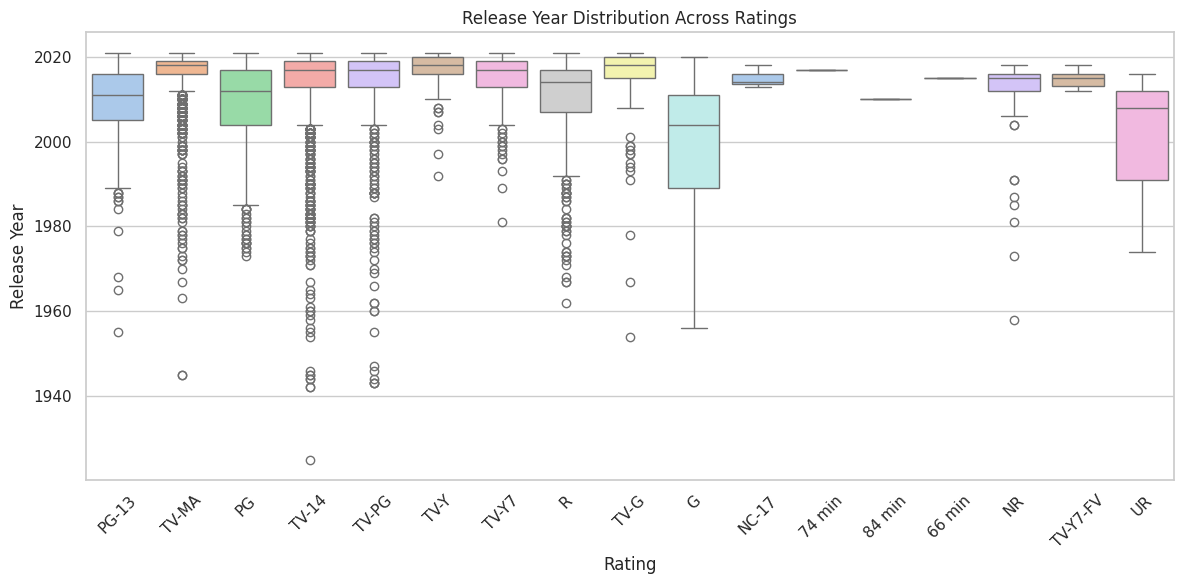

In [7]:
# Q5: Boxplot of release_year distribution across ratings

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="rating",
    y="release_year",
    palette="pastel",
    ax=ax
)

ax.set_title("Release Year Distribution Across Ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Release Year")
ax.tick_params(axis="x", rotation=45)   # rotate x labels to avoid overlap

plt.tight_layout()
plt.show()

### How it works

- `x="rating"` places each unique rating (TV-MA, PG-13, etc.) as a separate box on the x-axis.
- `y="release_year"` is what gets measured — each box shows how release years are spread within that rating.
- `ax.tick_params(axis="x", rotation=45)` rotates the rating labels so they don't overlap each other.
- The box shows the middle 50% of release years; the line inside is the median; dots are outliers.

**Key takeaway:** Swapping `hue` for `x` in `boxplot` is the cleanest way to compare a numeric distribution across many categories side by side.

**Q6.** Use `sns.violinplot()` to compare `release_year` distributions between Movies and TV Shows (`x="type"`, `y="release_year"`). Use `inner="quartile"` and a `"muted"` palette.
 

/tmp/ipykernel_77803/373137777.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


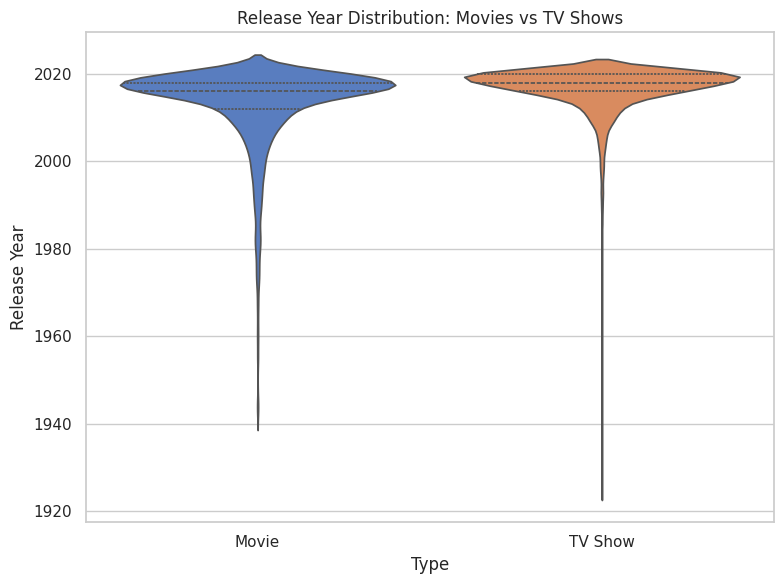

In [8]:
# Q6: Violinplot comparing release_year distribution by content type

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))

sns.violinplot(
    data=df,
    x="type",
    y="release_year",
    inner="quartile",   # draws quartile lines inside the violin instead of a box
    palette="muted",
    ax=ax
)

ax.set_title("Release Year Distribution: Movies vs TV Shows")
ax.set_xlabel("Type")
ax.set_ylabel("Release Year")

plt.tight_layout()
plt.show()

### How it works

- A violin plot is like a boxplot but with a mirrored KDE curve on each side — the wider the violin, the more titles exist at that year.
- `inner="quartile"` draws three dotted lines inside each violin representing Q1, median, and Q3.
- `x="type"` places Movies and TV Shows as two separate violins for direct comparison.
- `palette="muted"` uses slightly desaturated colors — good for professional or print-style charts.

**Key takeaway:** Violin plots show the full shape of a distribution (not just summary stats like a boxplot), making it easier to spot skew, peaks, and gaps in your data.

**Q7.** Find the top 10 most common content ratings (the `rating` column). Use `sns.barplot()` to show the count for each rating. Add value annotations on the bars. Use `hue="rating"` with `legend=False`.

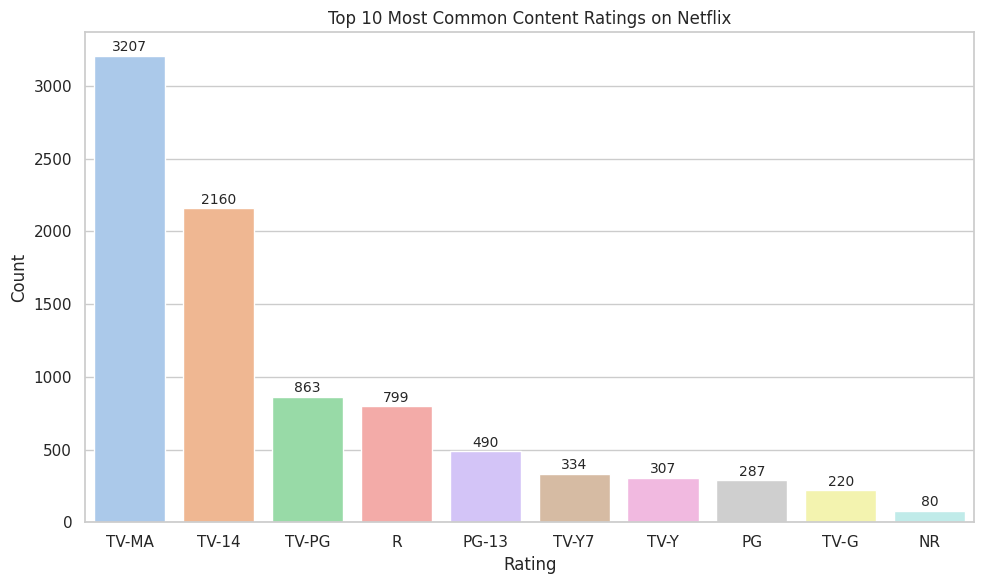

In [9]:
# Q7: Barplot of top 10 most common content ratings with value annotations

# Step 1: Get top 10 ratings by count
top10_ratings = df["rating"].value_counts().head(10).reset_index()
top10_ratings.columns = ["rating", "count"]   # rename for clarity

# Step 2: Plot
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top10_ratings,
    x="rating",
    y="count",
    hue="rating",        # color each bar differently
    palette="pastel",
    legend=False,        # hue is only for color — no legend needed
    ax=ax
)

# Step 3: Annotate each bar with its exact count
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # center of bar (x)
        bar.get_height() + 10,               # just above the bar (y)
        int(bar.get_height()),               # label text = count value
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("Top 10 Most Common Content Ratings on Netflix")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### How it works

- `value_counts().head(10)` counts occurrences of each rating and keeps the top 10; `.reset_index()` turns it into a plottable DataFrame.
- `hue="rating"` assigns a unique color to each bar; `legend=False` hides the redundant color legend since the x-axis already labels each bar.
- The `for bar in ax.patches` loop iterates over every bar rectangle drawn by seaborn.
- `bar.get_x() + bar.get_width() / 2` finds the horizontal center of each bar; `bar.get_height() + 10` places the label just above it.

**Key takeaway:** Use `ax.patches` to loop over bars and `ax.text()` to annotate them — this pattern works for any `barplot` regardless of the data.

**Q8.** Create a pivot table of the **count of titles** per `type` per decade. Add a `decade` column (`release_year // 10 * 10`). Use `sns.heatmap()` with `annot=True` and `fmt='d'` to display the pivot table as a heatmap.
 

type     Movie  TV Show
decade                 
1920       NaN      1.0
1940      13.0      2.0
1950      11.0      NaN
1960      23.0      2.0
1970      66.0      4.0
1980     122.0      7.0
1990     241.0     33.0
2000     677.0    133.0
2010    4184.0   1743.0
2020     794.0    751.0


ValueError: Unknown format code 'd' for object of type 'float'

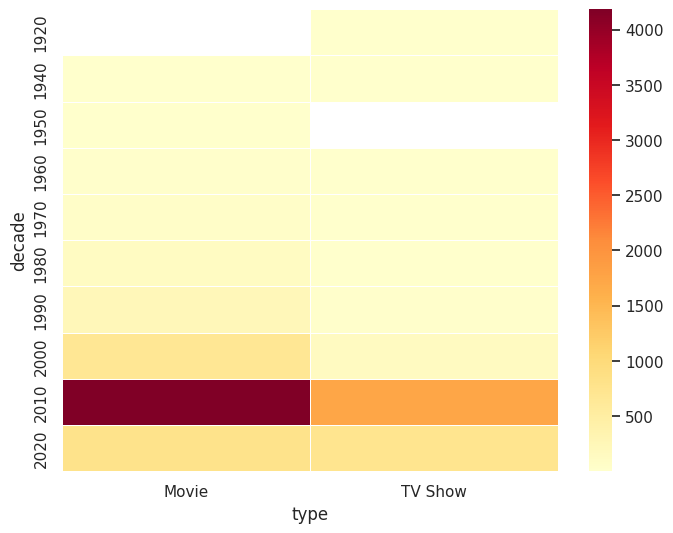

In [10]:
# Q8: Heatmap of title counts per type per decade

# Step 1: Add decade column
df["decade"] = (df["release_year"] // 10 * 10)   # e.g. 1994 → 1990

# Step 2: Build pivot table — rows=decade, cols=type, values=count
pivot = df.pivot_table(
    index="decade",
    columns="type",
    values="title",
    aggfunc="count"    # count titles in each decade/type cell
)

print(pivot)

# Step 3: Heatmap
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    pivot,
    annot=True,        # show numeric value inside each cell
    fmt="d",           # format as integer (no decimals)
    cmap="YlOrRd",     # yellow → orange → red gradient by intensity
    linewidths=0.5,    # thin grid lines between cells
    ax=ax
)

ax.set_title("Title Count per Type per Decade")
ax.set_xlabel("Type")
ax.set_ylabel("Decade")

plt.tight_layout()
plt.show()

type    Movie  TV Show
decade                
1920        0        1
1940       13        2
1950       11        0
1960       23        2
1970       66        4
1980      122        7
1990      241       33
2000      677      133
2010     4184     1743
2020      794      751


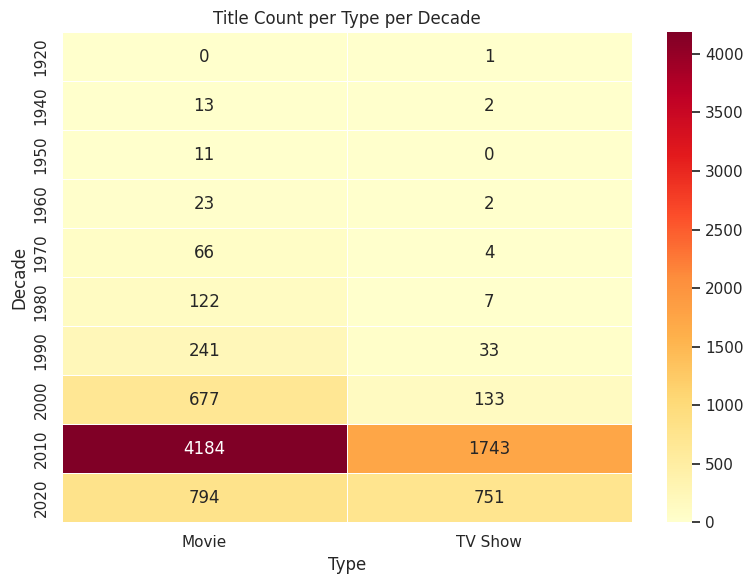

In [11]:
# Q8: Heatmap of title counts per type per decade

# Step 1: Add decade column
df["decade"] = (df["release_year"] // 10 * 10)

# Step 2: Build pivot table and fill NaN → 0, cast to int
pivot = df.pivot_table(
    index="decade",
    columns="type",
    values="title",
    aggfunc="count"
).fillna(0).astype(int)   # NaN decades get 0 count; int allows fmt="d"

print(pivot)

# Step 3: Heatmap
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Title Count per Type per Decade")
ax.set_xlabel("Type")
ax.set_ylabel("Decade")

plt.tight_layout()
plt.show()

### How it works

- `release_year // 10 * 10` uses integer division to snap any year to its decade start — e.g. `1994 // 10 = 199`, then `199 * 10 = 1990`.
- `pivot_table()` reshapes the DataFrame: each row is a decade, each column is a content type, and each cell holds the count of titles.
- `annot=True` prints the number inside every cell; `fmt="d"` formats those numbers as plain integers.
- `cmap="YlOrRd"` maps low counts to yellow and high counts to deep red, making hotspots immediately visible.

**Key takeaway:** A heatmap is most powerful when built from a pivot table — `pivot_table()` does the aggregation, `heatmap()` just handles the color-coded display.

**Q9.** Filter to Movies only. Use `sns.scatterplot()` to plot `release_year` (x) vs `duration_minutes` (y), with `hue="rating"` and `alpha=0.5`. Add a title.
 

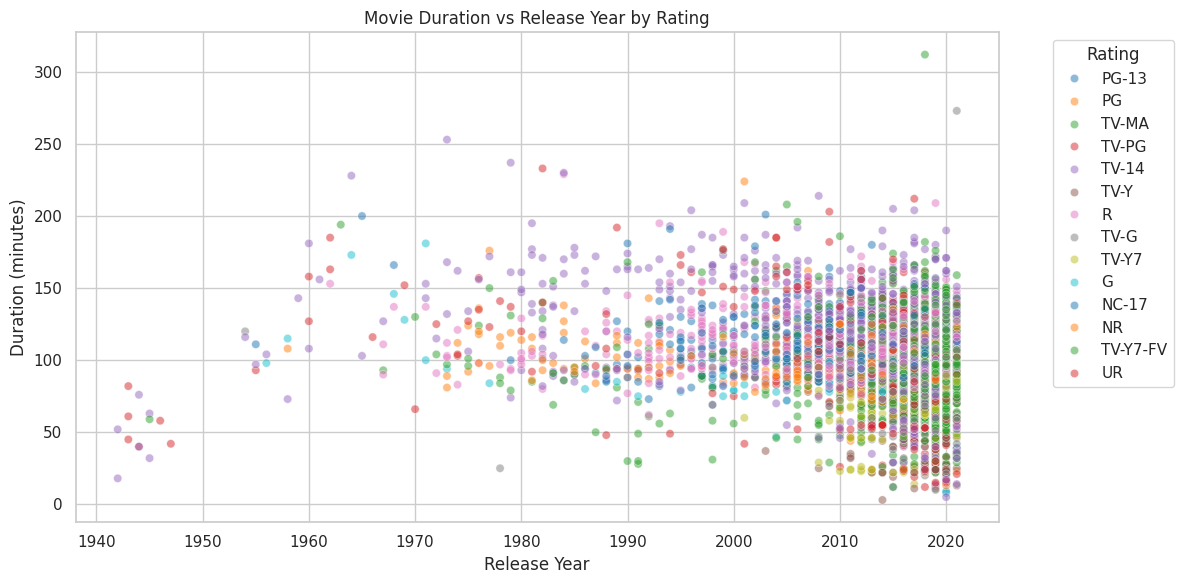

In [12]:
# Q9: Scatterplot of release_year vs duration_minutes for Movies

# Step 1: Filter movies and ensure duration_minutes exists
movies_df = df[df["type"] == "Movie"].copy()
movies_df["duration_minutes"] = (
    movies_df["duration"]
    .str.extract(r"(\d+)")
    .squeeze()
    .astype("Int64")
)
movies_df = movies_df.dropna(subset=["duration_minutes"])

# Step 2: Scatterplot
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=movies_df,
    x="release_year",
    y="duration_minutes",
    hue="rating",      # color each dot by content rating
    alpha=0.5,         # 50% transparency to reduce overplotting
    palette="tab10",   # distinct colors for many rating categories
    ax=ax
)

ax.set_title("Movie Duration vs Release Year by Rating")
ax.set_xlabel("Release Year")
ax.set_ylabel("Duration (minutes)")
ax.legend(title="Rating", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### How it works

- Each dot represents one Movie — its x position is the release year, y position is its runtime in minutes.
- `hue="rating"` assigns a unique color per rating (TV-MA, PG-13, etc.) so you can spot patterns per rating group.
- `alpha=0.5` makes dots semi-transparent — when many dots overlap (overplotting), you can still see the density.
- `bbox_to_anchor=(1.05, 1)` moves the legend just outside the plot so it doesn't cover the data.

**Key takeaway:** Use `alpha` whenever dots overlap heavily in a scatterplot — it turns a solid blob into a readable density map.

**Q10.** Use `sns.countplot()` with `y="rating"` (horizontal) and `hue="type"` to compare the rating distribution between Movies and TV Shows. Use a `"Set2"` palette.

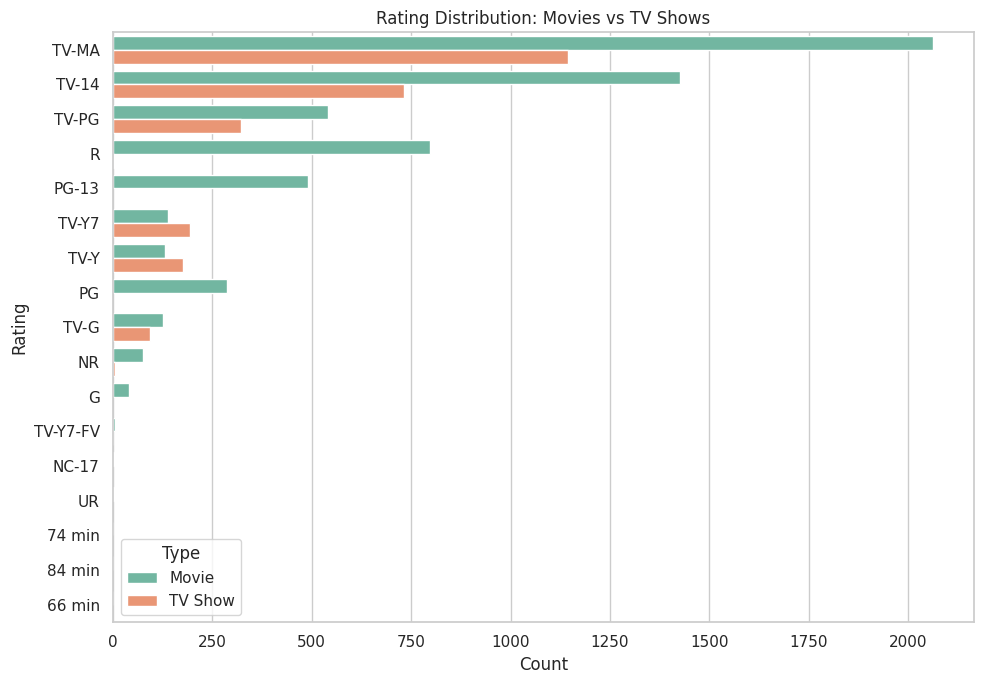

In [13]:
# Q10: Horizontal countplot of rating distribution by content type

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 7))

sns.countplot(
    data=df,
    y="rating",          # y= makes the bars horizontal
    hue="type",          # split each rating bar by Movie vs TV Show
    palette="Set2",
    order=df["rating"].value_counts().index,   # sort by most common rating
    ax=ax
)

ax.set_title("Rating Distribution: Movies vs TV Shows")
ax.set_xlabel("Count")
ax.set_ylabel("Rating")
ax.legend(title="Type")

plt.tight_layout()
plt.show()

### How it works

- `y="rating"` instead of `x="rating"` flips the bars horizontal — useful when category labels are long or there are many of them.
- `hue="type"` splits each rating into two side-by-side bars (one per content type) for direct comparison.
- `order=df["rating"].value_counts().index` sorts ratings from most to least frequent, making the chart easier to scan top to bottom.
- `palette="Set2"` uses a colorblind-friendly set of distinct colors.

**Key takeaway:** Use `y=` for horizontal bars whenever x-axis labels overlap or there are more than ~6 categories — it's the same plot, just rotated for readability.

**Q11.** Extract the first genre from `listed_in` into a new column `primary_genre` (split on `","` and take the first item). Use `sns.countplot()` to show the top 10 genres. Rotate x labels.

/tmp/ipykernel_77803/743251967.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


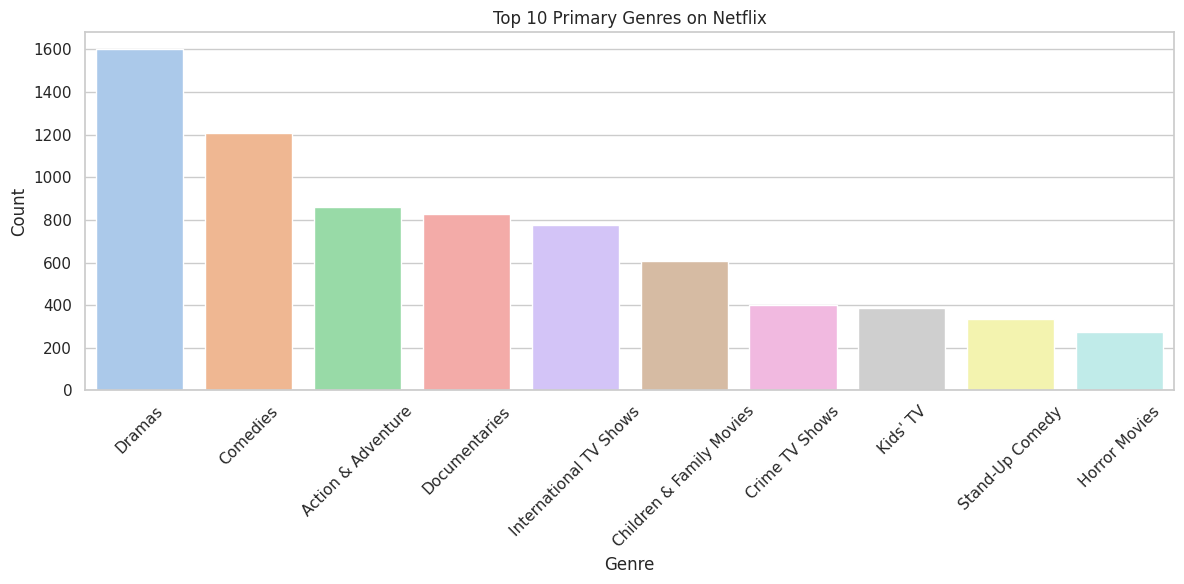

primary_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       774
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     388
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64


In [14]:
# Q11: Extract primary genre and plot top 10 with countplot

# Step 1: Extract first genre from comma-separated listed_in
df["primary_genre"] = (
    df["listed_in"]
    .str.split(",")          # "Dramas, International Movies" → ["Dramas", " International Movies"]
    .str[0]                  # take first item
    .str.strip()             # remove leading/trailing whitespace
)

# Step 2: Find top 10 genres for ordering
top10_genres = df["primary_genre"].value_counts().head(10).index

# Step 3: Filter to top 10 and plot
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.countplot(
    data=df[df["primary_genre"].isin(top10_genres)],
    x="primary_genre",
    order=top10_genres,      # sort bars by frequency
    palette="pastel",
    ax=ax
)

ax.set_title("Top 10 Primary Genres on Netflix")
ax.set_xlabel("Genre")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(df["primary_genre"].value_counts().head(10))

### How it works

- `.str.split(",")` splits each string on commas into a list; `.str[0]` indexes into that list to grab only the first genre.
- `.str.strip()` removes any accidental spaces left after splitting (e.g. `" Dramas"` → `"Dramas"`).
- `top10_genres` is computed first and passed to both `isin()` (to filter rows) and `order=` (to sort bars by frequency).
- Without `order=`, seaborn would sort bars alphabetically instead of by count.

**Key takeaway:** Always compute your `order=` list from `value_counts().index` before plotting — it ensures bars are ranked by frequency, not sorted arbitrarily.

**Q12.** Use `sns.stripplot()` with `x="type"`, `y="release_year"`, and `jitter=True` to show the spread of release years for Movies vs TV Shows. Overlay a `sns.boxplot()` on the same axes (set `boxprops={"zorder": 2}` and `whiskerprops={"zorder": 2}`).

/tmp/ipykernel_77803/2965289672.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_77803/2965289672.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


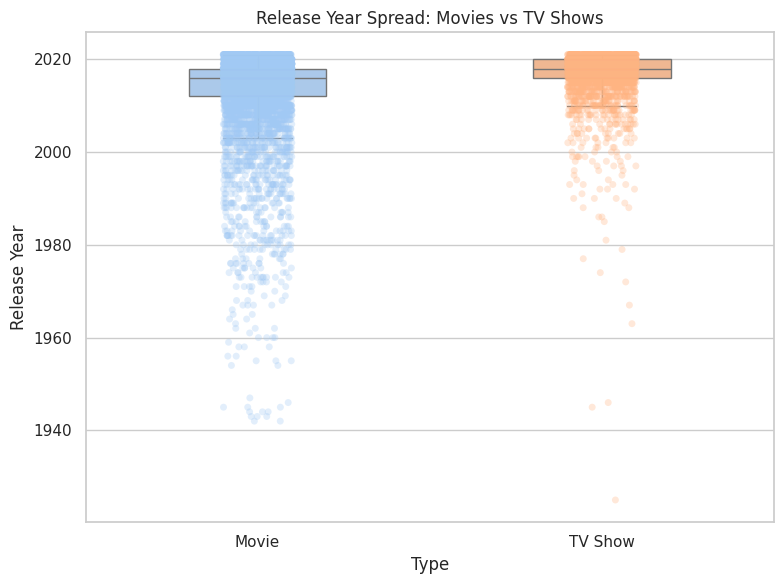

In [15]:
# Q12: Stripplot overlaid with boxplot for release_year by type

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))

# Step 1: Draw stripplot first (behind the boxplot)
sns.stripplot(
    data=df,
    x="type",
    y="release_year",
    jitter=True,         # randomly scatter dots horizontally to reduce overlap
    alpha=0.3,           # transparent dots so boxplot stays visible on top
    palette="pastel",
    ax=ax
)

# Step 2: Overlay boxplot on top using zorder to keep it in front
sns.boxplot(
    data=df,
    x="type",
    y="release_year",
    palette="pastel",
    width=0.4,           # narrower box so strip dots are visible on sides
    flierprops={"marker": ""},          # hide boxplot outlier dots (strip shows them)
    boxprops={"zorder": 2},             # draw box above strip dots
    whiskerprops={"zorder": 2},         # draw whiskers above strip dots
    ax=ax
)

ax.set_title("Release Year Spread: Movies vs TV Shows")
ax.set_xlabel("Type")
ax.set_ylabel("Release Year")

plt.tight_layout()
plt.show()

### How it works

- `sns.stripplot()` plots every individual title as a dot; `jitter=True` nudges dots sideways randomly so they don't all stack in one line.
- `alpha=0.3` makes the dots faint so the boxplot drawn on top remains clearly readable.
- Drawing the stripplot first and boxplot second means the box naturally sits in front — `zorder=2` enforces this explicitly.
- `flierprops={"marker": ""}` hides the boxplot's built-in outlier dots since the stripplot already shows every point.

**Key takeaway:** Strip + box overlays work best when you draw the strip first (background) and box second (foreground) — `zorder` gives you explicit control over which layer sits on top.

**Q13.** Create a new column `added_year` by extracting the year from `date_added` (use `pd.to_datetime()` then `.dt.year`). Use `sns.lineplot()` to show the **number of titles added per year**, with separate lines for Movies and TV Shows using `hue="type"`.

    added_year     type  count
0       2008.0    Movie      1
1       2008.0  TV Show      1
2       2009.0    Movie      2
3       2010.0    Movie      1
4       2011.0    Movie     13
5       2012.0    Movie      3
6       2013.0    Movie      6
7       2013.0  TV Show      4
8       2014.0    Movie     19
9       2014.0  TV Show      4
10      2015.0    Movie     56
11      2015.0  TV Show     17
12      2016.0    Movie    253
13      2016.0  TV Show    165
14      2017.0    Movie    839
15      2017.0  TV Show    325
16      2018.0    Movie   1237
17      2018.0  TV Show    388
18      2019.0    Movie   1424
19      2019.0  TV Show    575
20      2020.0    Movie   1284
21      2020.0  TV Show    594
22      2021.0    Movie    993
23      2021.0  TV Show    505


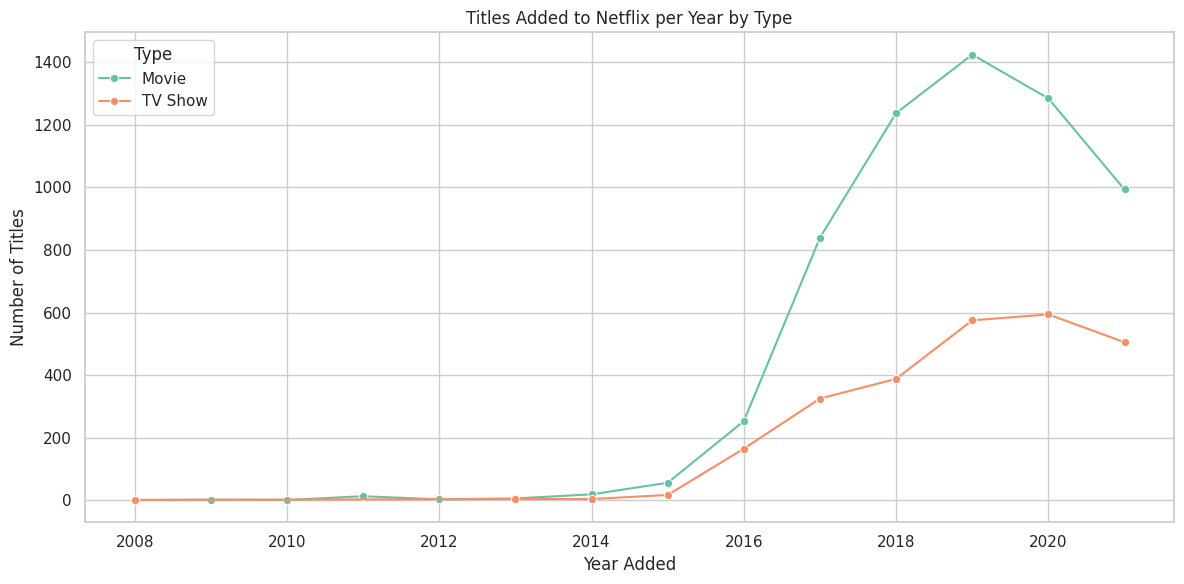

In [16]:
# Q13: Lineplot of titles added per year by content type

# Step 1: Parse date_added and extract year
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")  # coerce bad dates to NaT
df["added_year"] = df["date_added"].dt.year

# Step 2: Count titles per year per type
yearly_counts = (
    df.dropna(subset=["added_year"])          # drop rows with no date
    .groupby(["added_year", "type"])
    .size()
    .reset_index(name="count")
)

print(yearly_counts)

# Step 3: Lineplot
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=yearly_counts,
    x="added_year",
    y="count",
    hue="type",           # separate line per content type
    marker="o",           # dot at each year point for readability
    palette="Set2",
    ax=ax
)

ax.set_title("Titles Added to Netflix per Year by Type")
ax.set_xlabel("Year Added")
ax.set_ylabel("Number of Titles")
ax.legend(title="Type")

plt.tight_layout()
plt.show()

### How it works

- `pd.to_datetime(..., errors="coerce")` converts the `date_added` string column into proper datetime objects; `errors="coerce"` turns any unparseable dates into `NaT` (Not a Time) instead of crashing.
- `.dt.year` extracts just the year integer from each datetime value.
- `.groupby(["added_year", "type"]).size()` counts how many titles fall in each year+type combination.
- `hue="type"` draws one line per content type on the same axes, making year-over-year growth easy to compare.

**Key takeaway:** Always use `errors="coerce"` with `pd.to_datetime()` on real-world data — dirty date strings are common, and coercing prevents crashes while keeping the rest of your data intact.

**Q14.** Filter to the top 5 countries by number of titles. Use `sns.countplot()` with `hue="type"` and `x="country"` to show the Movie vs TV Show breakdown for each country. Rotate x labels.

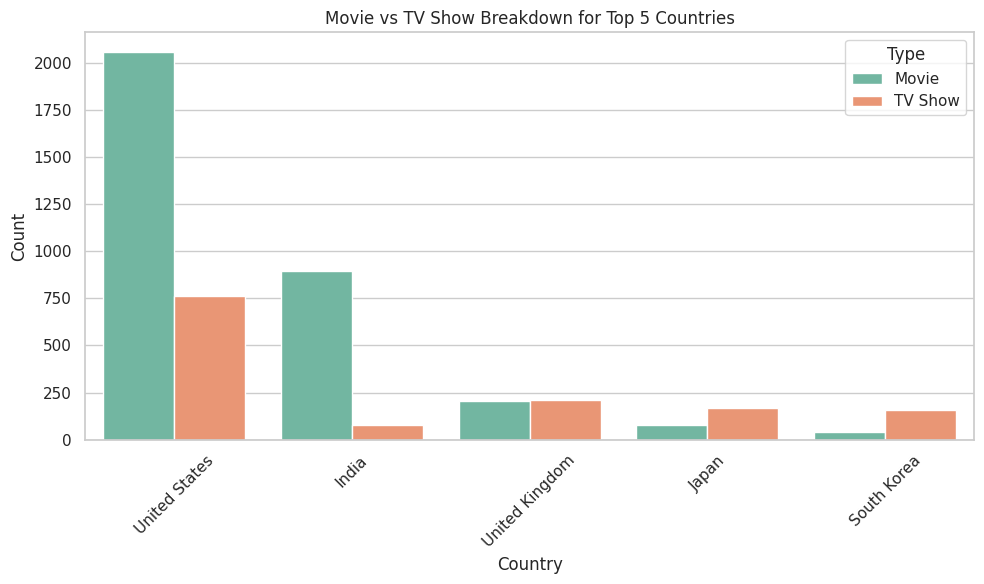

type            Movie  TV Show
country                       
India             893       79
Japan              76      169
South Korea        41      158
United Kingdom    206      213
United States    2058      760


In [17]:
# Q14: Countplot of Movie vs TV Show breakdown for top 5 countries

# Step 1: Find top 5 countries by total title count
top5_countries = df["country"].value_counts().head(5).index

# Step 2: Filter dataframe to top 5 countries only
top5_df = df[df["country"].isin(top5_countries)]

# Step 3: Countplot
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=top5_df,
    x="country",
    hue="type",
    order=top5_countries,     # sort by most titles
    palette="Set2",
    ax=ax
)

ax.set_title("Movie vs TV Show Breakdown for Top 5 Countries")
ax.set_xlabel("Country")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Type")

plt.tight_layout()
plt.show()

# Print exact counts for verification
print(top5_df.groupby(["country", "type"]).size().unstack(fill_value=0))

### How it works

- `value_counts().head(5).index` gives the top 5 country names ranked by total titles — passing this to `order=` keeps bars sorted by frequency.
- `isin(top5_countries)` filters the DataFrame to only rows belonging to those 5 countries.
- `hue="type"` splits each country bar into two side-by-side bars — one for Movies, one for TV Shows.
- `.unstack(fill_value=0)` at the end reshapes the grouped counts into a readable table with countries as rows and types as columns.

**Key takeaway:** Always pass the same `value_counts().index` list to both `isin()` (for filtering) and `order=` (for sorting) — this guarantees your filter and your bar order stay in sync.

**Q15.** Create a small correlation heatmap using only numeric columns (`release_year`, `duration_minutes`). Compute `.corr()` and plot it with `sns.heatmap()` using `annot=True`, `cmap="coolwarm"`, and `vmin=-1`, `vmax=1`.

                  release_year  duration_minutes
release_year          1.000000         -0.206285
duration_minutes     -0.206285          1.000000


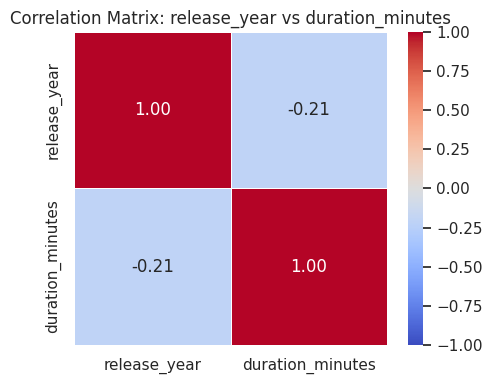

In [18]:
# Q15: Correlation heatmap of numeric columns

# Step 1: Build movies_df with duration_minutes if not already in df
movies_df = df[df["type"] == "Movie"].copy()
movies_df["duration_minutes"] = (
    movies_df["duration"]
    .str.extract(r"(\d+)")
    .squeeze()
    .astype("Int64")
)

# Step 2: Select numeric columns and compute correlation matrix
numeric_df = movies_df[["release_year", "duration_minutes"]].dropna()
corr_matrix = numeric_df.corr()

print(corr_matrix)

# Step 3: Heatmap
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    corr_matrix,
    annot=True,          # show correlation value inside each cell
    fmt=".2f",           # 2 decimal places (correlation is float, not int)
    cmap="coolwarm",     # blue = negative, white = zero, red = positive
    vmin=-1, vmax=1,     # fix scale to full correlation range [-1, 1]
    linewidths=0.5,
    square=True,         # make each cell square for a cleaner look
    ax=ax
)

ax.set_title("Correlation Matrix: release_year vs duration_minutes")

plt.tight_layout()
plt.show()

### How it works

- `.corr()` computes the Pearson correlation (a number from -1 to +1) between every pair of numeric columns — here just `release_year` and `duration_minutes`.
- `vmin=-1, vmax=1` pins the colormap to the full correlation range so colors are always meaningful — without this, a weak correlation might look strong just because the range is narrow.
- `cmap="coolwarm"` maps -1 (strong negative) to blue, 0 to white, and +1 (strong positive) to red.
- `fmt=".2f"` is used instead of `fmt="d"` because correlation values are floats like `0.23`, not integers.
- `square=True` forces equal cell dimensions, which looks cleaner on small matrices.

**Key takeaway:** Always set `vmin=-1, vmax=1` on correlation heatmaps — without it, the color scale auto-fits to your data range and can visually exaggerate weak correlations.